In [2]:
!pip install unsloth scikit-learn datasets pandas matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

###**Block 2 — Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from unsloth import FastLanguageModel
import torch

print("GPU available:", torch.cuda.is_available())
print("All libraries imported!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU available: True
All libraries imported!


### **Define Intent Mapping**

In [4]:
ATIS_INTENT_MAPPING = {
    'abbreviation': "Abbreviation and Fare Code Meaning Inquiry",
    'aircraft':     "Aircraft Type Inquiry",
    'airfare':      "Airfare and Fares Questions",
    'airline':      "Airline Information Request",
    'airport':      "Airport Information and Queries",
    'capacity':     "Aircraft Seating Capacity Inquiry",
    'cheapest':     "Cheapest Fare Inquiry",
    'city':         "Airport Location Inquiry",
    'distance':     "Airport Distance Inquiry",
    'flight':       "Flight Booking Request",
    'flight_no':    "Flight Number Inquiry",
    'flight_time':  "Time Inquiry",
    'ground_fare':  "Ground Transportation Cost Inquiry",
    'ground_service': "Ground Transportation Inquiry",
    'meal':         "Inquiry about In-flight Meals",
    'quantity':     "Flight Quantity Inquiry",
    'restriction':  "Flight Restriction Inquiry",
}

LABELS = list(ATIS_INTENT_MAPPING.values())
print(f"Total intent categories: {len(ATIS_INTENT_MAPPING)}")

Total intent categories: 17


### **Load and Prepare Dataset**

In [5]:
print("Loading ATIS dataset from Hugging Face...")
dataset = load_dataset("tuetschek/atis")
dataset.set_format(type="pandas")

samples  = dataset["train"][:]
df_test  = dataset["test"][:]

samples["label"] = samples["intent"].apply(lambda x: ATIS_INTENT_MAPPING.get(x))
df_test["label"] = df_test["intent"].apply(lambda x: ATIS_INTENT_MAPPING.get(x))

samples.dropna(subset=["label"], inplace=True)
df_test.dropna(subset=["label"], inplace=True)

df_train, df_valid = train_test_split(samples, test_size=0.15, random_state=42)

print(f"Train samples  : {len(df_train)}")
print(f"Valid samples  : {len(df_valid)}")
print(f"Test  samples  : {len(df_test)}")
print(f"Intent categories: {df_train['intent'].nunique()}")
display(df_train.head(3))

Loading ATIS dataset from Hugging Face...


atis_train.csv: 0.00B [00:00, ?B/s]

atis_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/893 [00:00<?, ? examples/s]

Train samples  : 4209
Valid samples  : 743
Test  samples  : 876
Intent categories: 17


,id,intent,text,slots,label
1571,1571,flight,show me the cheapest flights from baltimore to...,O O O B-cost_relative O O B-fromloc.city_name ...,Flight Booking Request
3722,3722,flight,list flights between denver and pittsburgh,O O O B-fromloc.city_name O B-toloc.city_name,Flight Booking Request
3454,3454,flight,on april fifteenth i would like an early morni...,O B-depart_date.month_name B-depart_date.day_n...,Flight Booking Request


### **Train TF-IDF + Logistic Regression**

In [6]:
print("=" * 60)
print("MODEL 1: TF-IDF + Logistic Regression")
print("=" * 60)

le = LabelEncoder()
df_train_copy = df_train.copy()
df_valid_copy = df_valid.copy()
df_test_copy  = df_test.copy()

df_train_copy["label_enc"] = le.fit_transform(df_train_copy["intent"])
df_valid_copy["label_enc"] = le.transform(df_valid_copy["intent"])
df_test_copy["label_enc"]  = le.transform(df_test_copy["intent"])

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(df_train_copy["text"])
X_valid = vectorizer.transform(df_valid_copy["text"])
X_test  = vectorizer.transform(df_test_copy["text"])

y_train = df_train_copy["label_enc"]
y_valid = df_valid_copy["label_enc"]
y_test  = df_test_copy["label_enc"]

start_time = time.time()
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
train_time_tfidf = time.time() - start_time

start_time = time.time()
preds_tfidf = clf.predict(X_test)
inference_time_tfidf = time.time() - start_time

accuracy_tfidf = accuracy_score(y_test, preds_tfidf)
macro_f1_tfidf = f1_score(y_test, preds_tfidf, average="macro")

print(f"Training Time  : {train_time_tfidf:.2f} seconds")
print(f"Inference Time : {inference_time_tfidf:.4f} seconds ({len(y_test)} samples)")
print(f"Accuracy       : {accuracy_tfidf:.4f}")
print(f"Macro-F1 Score : {macro_f1_tfidf:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(
    y_test, preds_tfidf,
    labels=le.transform(le.classes_),
    target_names=le.classes_
))

MODEL 1: TF-IDF + Logistic Regression
Training Time  : 0.68 seconds
Inference Time : 0.0009 seconds (876 samples)
Accuracy       : 0.8984
Macro-F1 Score : 0.5033

Detailed Classification Report:
                precision    recall  f1-score   support

  abbreviation       1.00      0.97      0.98        33
      aircraft       0.47      0.89      0.62         9
       airfare       0.91      0.85      0.88        48
       airline       1.00      0.74      0.85        38
       airport       1.00      0.11      0.20        18
      capacity       1.00      0.33      0.50        21
      cheapest       0.00      0.00      0.00         0
          city       0.00      0.00      0.00         6
      distance       1.00      0.30      0.46        10
        flight       0.90      0.99      0.94       632
     flight_no       0.00      0.00      0.00         8
   flight_time       0.00      0.00      0.00         1
   ground_fare       1.00      0.57      0.73         7
ground_service      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

### **Helper: Evaluate LLM Predictions**

In [7]:
from difflib import get_close_matches

def evaluate_llm_predictions(true_labels, pred_labels, model_name):
    cleaned_preds = []
    for pred in pred_labels:
        pred = pred.strip()
        if pred in LABELS:
            cleaned_preds.append(pred)
        else:
            matches = get_close_matches(pred, LABELS, n=1, cutoff=0.4)
            cleaned_preds.append(matches[0] if matches else LABELS[0])

    correct   = sum(1 for t, p in zip(true_labels, cleaned_preds) if t == p)
    accuracy  = correct / len(true_labels)

    label_to_idx = {label: i for i, label in enumerate(LABELS)}
    true_idx = [label_to_idx.get(t, 0) for t in true_labels]
    pred_idx = [label_to_idx.get(p, 0) for p in cleaned_preds]
    macro_f1 = f1_score(true_idx, pred_idx, average="macro", zero_division=0)

    print(f"\n{model_name} Results ({len(true_labels)} samples):")
    print(f"  Accuracy       : {accuracy:.4f}")
    print(f"  Macro-F1 Score : {macro_f1:.4f}")

    return accuracy, macro_f1, cleaned_preds

# Sample 100 test sentences for LLM evaluation (saves GPU time)
df_test_sample    = df_test_copy.sample(n=100, random_state=42)
test_texts_sample = df_test_sample["text"].tolist()
test_labels_sample = df_test_sample["label"].tolist()

results = {
    "TF-IDF + Logistic Regression": {
        "accuracy":         accuracy_tfidf,
        "macro_f1":         macro_f1_tfidf,
        "train_time":       train_time_tfidf,
        "inference_time":   inference_time_tfidf,
        "requires_gpu":     False,
        "requires_training": True,
    }
}

print("Helper functions ready. Test sample size:", len(test_texts_sample))

Helper functions ready. Test sample size: 100


### **LLaMA 3.2-3B**

In [8]:
print("=" * 60)
print("MODEL 2: LLaMA 3.2-3B (In-Context Learning)")
print("=" * 60)

llama_model, llama_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-3B-Instruct",
    max_seq_length=256,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(llama_model)

def classify_intent_llama(text):
    label_list = "\n".join(f"- {l}" for l in LABELS)
    prompt = f"""Classify the following airline query into EXACTLY ONE of these intents:
{label_list}

Query: "{text}"
Reply with only the intent name, nothing else.
Intent:"""
    inputs  = llama_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = llama_model.generate(**inputs, max_new_tokens=20, temperature=1, do_sample=False)
    result  = llama_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result.split("Intent:")[-1].strip()

start_time  = time.time()
llama_preds = [classify_intent_llama(text) for text in test_texts_sample]
llama_inference_time = time.time() - start_time

llama_acc, llama_f1, llama_preds_clean = evaluate_llm_predictions(
    test_labels_sample, llama_preds, "LLaMA 3.2-3B"
)
print(f"  Inference Time : {llama_inference_time:.2f} seconds")

results["LLaMA 3.2-3B"] = {
    "accuracy":          llama_acc,
    "macro_f1":          llama_f1,
    "train_time":        0,
    "inference_time":    llama_inference_time,
    "requires_gpu":      True,
    "requires_training": False,
}

# Free GPU memory
del llama_model, llama_tokenizer
torch.cuda.empty_cache()
print("\nLLaMA unloaded from GPU memory.")

MODEL 2: LLaMA 3.2-3B (In-Context Learning)
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.mask


LLaMA 3.2-3B Results (100 samples):
  Accuracy       : 0.2600
  Macro-F1 Score : 0.2045
  Inference Time : 55.22 seconds

LLaMA unloaded from GPU memory.


### **Gemma 2-2B IT**

In [9]:
print("=" * 60)
print("MODEL 3: Gemma 2-2B IT (In-Context Learning)")
print("=" * 60)

gemma_model, gemma_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-2-2b-it",
    max_seq_length=256,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(gemma_model)

def classify_intent_gemma(text):
    label_list = "\n".join(f"- {l}" for l in LABELS)
    prompt = f"""<start_of_turn>user
Classify the following airline query into EXACTLY ONE of these intents:
{label_list}

Query: "{text}"
Reply with only the intent name, nothing else.<end_of_turn>
<start_of_turn>model
"""
    inputs  = gemma_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = gemma_model.generate(**inputs, max_new_tokens=20, temperature=1, do_sample=False)
    result  = gemma_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result.split("<start_of_turn>model")[-1].strip()

start_time  = time.time()
gemma_preds = [classify_intent_gemma(text) for text in test_texts_sample]
gemma_inference_time = time.time() - start_time

gemma_acc, gemma_f1, gemma_preds_clean = evaluate_llm_predictions(
    test_labels_sample, gemma_preds, "Gemma 2-2B IT"
)
print(f"  Inference Time : {gemma_inference_time:.2f} seconds")

results["Gemma 2-2B IT"] = {
    "accuracy":          gemma_acc,
    "macro_f1":          gemma_f1,
    "train_time":        0,
    "inference_time":    gemma_inference_time,
    "requires_gpu":      True,
    "requires_training": False,
}

del gemma_model, gemma_tokenizer
torch.cuda.empty_cache()
print("\nGemma unloaded from GPU memory.")

MODEL 3: Gemma 2-2B IT (In-Context Learning)
==((====))==  Unsloth 2026.5.2: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warn


Gemma 2-2B IT Results (100 samples):
  Accuracy       : 0.0700
  Macro-F1 Score : 0.0131
  Inference Time : 31.52 seconds

Gemma unloaded from GPU memory.


### **Phi-3 Mini 4K**

In [10]:
print("=" * 60)
print("MODEL 4: Phi-3 Mini 4K (In-Context Learning)")
print("=" * 60)

phi3_model, phi3_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Phi-3-mini-4k-instruct",
    max_seq_length=256,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(phi3_model)

def classify_intent_phi3(text):
    label_list = "\n".join(f"- {l}" for l in LABELS)
    prompt = f"""<|user|>
Classify the following airline query into EXACTLY ONE of these intents:
{label_list}

Query: "{text}"
Reply with only the intent name, nothing else.<|end|>
<|assistant|>
"""
    inputs  = phi3_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = phi3_model.generate(**inputs, max_new_tokens=20, temperature=1, do_sample=False)
    result  = phi3_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result.split("<|assistant|>")[-1].strip()

start_time = time.time()
phi3_preds = [classify_intent_phi3(text) for text in test_texts_sample]
phi3_inference_time = time.time() - start_time

phi3_acc, phi3_f1, phi3_preds_clean = evaluate_llm_predictions(
    test_labels_sample, phi3_preds, "Phi-3 Mini 4K"
)
print(f"  Inference Time : {phi3_inference_time:.2f} seconds")

results["Phi-3 Mini 4K"] = {
    "accuracy":          phi3_acc,
    "macro_f1":          phi3_f1,
    "train_time":        0,
    "inference_time":    phi3_inference_time,
    "requires_gpu":      True,
    "requires_training": False,
}

del phi3_model, phi3_tokenizer
torch.cuda.empty_cache()
print("\nPhi-3 unloaded from GPU memory.")

MODEL 4: Phi-3 Mini 4K (In-Context Learning)
==((====))==  Unsloth 2026.5.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/d


Phi-3 Mini 4K Results (100 samples):
  Accuracy       : 0.0700
  Macro-F1 Score : 0.0131
  Inference Time : 52.24 seconds

Phi-3 unloaded from GPU memory.


### **Final Comparison Table**

In [11]:
print("\n" + "=" * 70)
print("FINAL COMPARISON TABLE")
print("=" * 70)

comparison_df = pd.DataFrame([
    {
        "Model":              name,
        "Accuracy":           f"{vals['accuracy']:.4f}",
        "Macro-F1":           f"{vals['macro_f1']:.4f}",
        "Train Time (s)":     f"{vals['train_time']:.2f}",
        "Inference Time (s)": f"{vals['inference_time']:.2f}",
        "GPU Required":       "Yes" if vals["requires_gpu"] else "No",
        "Training Needed":    "Yes" if vals["requires_training"] else "No",
    }
    for name, vals in results.items()
])

display(comparison_df)
print("\nBest Macro-F1  :", max(results, key=lambda x: results[x]["macro_f1"]))
print("Fastest model  : TF-IDF + Logistic Regression")
print("Most flexible  : LLM models (no retraining needed)")


FINAL COMPARISON TABLE


,Model,Accuracy,Macro-F1,Train Time (s),Inference Time (s),GPU Required,Training Needed
0,TF-IDF + Logistic Regression,0.8984,0.5033,0.68,0.00,No,Yes
1,LLaMA 3.2-3B,0.2600,0.2045,0.00,55.22,Yes,No
2,Gemma 2-2B IT,0.0700,0.0131,0.00,31.52,Yes,No
3,Phi-3 Mini 4K,0.0700,0.0131,0.00,52.24,Yes,No



Best Macro-F1  : TF-IDF + Logistic Regression
Fastest model  : TF-IDF + Logistic Regression
Most flexible  : LLM models (no retraining needed)


### **Comparison Charts**

/tmp/ipykernel_5115/1013811978.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(model_names, rotation=15, ha="right")
/tmp/ipykernel_5115/1013811978.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=15, ha="right")
/tmp/ipykernel_5115/1013811978.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(model_names, rotation=15, ha="right")


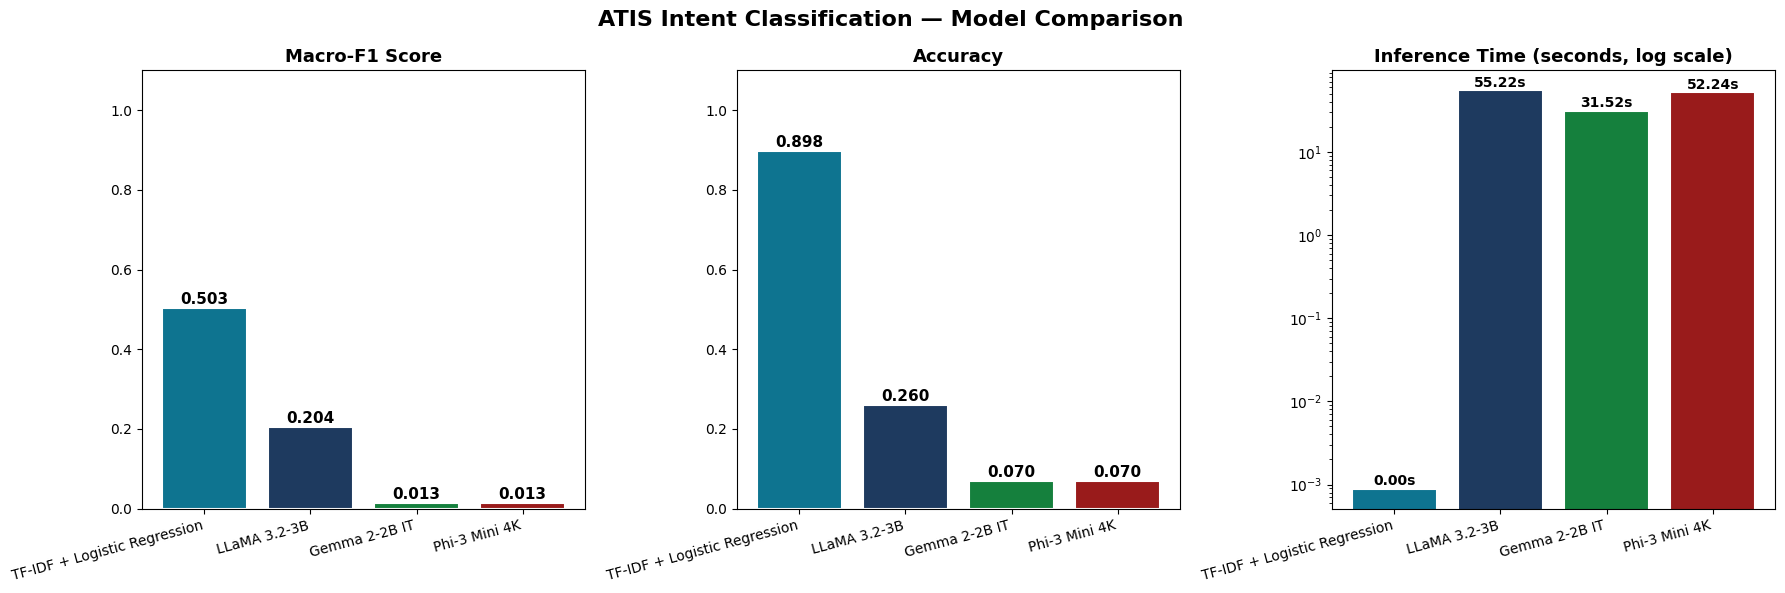

Chart saved as model_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("ATIS Intent Classification — Model Comparison", fontsize=16, fontweight="bold")

model_names     = list(results.keys())
f1_scores       = [results[m]["macro_f1"]       for m in model_names]
accuracies      = [results[m]["accuracy"]        for m in model_names]
inference_times = [results[m]["inference_time"]  for m in model_names]
colors = ["#0E7490", "#1E3A5F", "#15803D", "#991B1B"]

# Chart 1 — Macro-F1
bars1 = axes[0].bar(model_names, f1_scores, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Macro-F1 Score", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(model_names, rotation=15, ha="right")
for bar, val in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

# Chart 2 — Accuracy
bars2 = axes[1].bar(model_names, accuracies, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 1.1)
axes[1].set_xticklabels(model_names, rotation=15, ha="right")
for bar, val in zip(bars2, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

# Chart 3 — Inference Time (log scale)
bars3 = axes[2].bar(model_names, inference_times, color=colors, edgecolor="white", linewidth=1.5)
axes[2].set_title("Inference Time (seconds, log scale)", fontsize=13, fontweight="bold")
axes[2].set_yscale("log")
axes[2].set_xticklabels(model_names, rotation=15, ha="right")
for bar, val in zip(bars3, inference_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f"{val:.2f}s", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as model_comparison.png")

### **Quick Test on Sample Sentences**

In [13]:
print("=" * 70)
print("QUICK TEST — Same queries through TF-IDF model")
print("=" * 70)

TEST_QUERIES = [
    "i need flights that arrive in baltimore from ankara",
    "what is the cheapest fare from new york to chicago",
    "which airlines fly from boston to denver",
    "how many seats does a boeing 747 have",
    "what is the ground transportation from the airport",
]

X_new       = vectorizer.transform(TEST_QUERIES)
tfidf_preds = le.inverse_transform(clf.predict(X_new))

for query, pred in zip(TEST_QUERIES, tfidf_preds):
    print(f"  Input  : {query}")
    print(f"  Intent : {pred}")
    print()

QUICK TEST — Same queries through TF-IDF model
  Input  : i need flights that arrive in baltimore from ankara
  Intent : flight

  Input  : what is the cheapest fare from new york to chicago
  Intent : airfare

  Input  : which airlines fly from boston to denver
  Intent : airline

  Input  : how many seats does a boeing 747 have
  Intent : quantity

  Input  : what is the ground transportation from the airport
  Intent : ground_service

